# Random Forest

In [1]:
## ● Use the Glass dataset and apply the Random forest model.

#### Data Description:

In [2]:
## RI : refractive index
## Na: Sodium (unit measurement: weight percent in corresponding oxide, as are attributes 4-10)
## Mg: Magnesium
## AI: Aluminum
## Si: Silicon
## K:Potassium
## Ca: Calcium
## Ba: Barium
## Fe: Iron
## Type: Type of glass: (class attribute)

## 1 -- building_windows_float_processed
## 2 --building_windows_non_float_processed
## 3 --vehicle_windows_float_processed
## 4 --vehicle_windows_non_float_processed (none in this database)
## 5 --containers
## 6 --tableware
## 7 --headlamps

### 1. Exploratory Data Analysis (EDA):

In [3]:
## ● Perform exploratory data analysis to understand the structure of the dataset.
## ● Check for missing values, outliers, inconsistencies in the data.

In [4]:
import pandas as pd
import numpy as np 

In [5]:
df = pd.read_excel("glass.xlsx")
df.head(2)

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [7]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [8]:
## The dataset contain 214 records and 10 columns.. all features are of numeric datatype including the target variable (Type)..
## There are no missing values in the dataset so no imputation is required.. dataset is clean and ready for further analysis..

In [9]:
df['Type'].value_counts()

Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64

In [10]:
## The target variable 'Type' is a multi class variable with 6 categories..
## The distribution of classes is kind of uneven (imbalanced feature).. also class (Type 4) is missing..
## Type 1 & 2 have highest number  of samples while Type 5 & 6 have very few observations..
## The imbalance in the data can affect the model performance.. possiblity of model to become biased toward majority classes increases..

### 2: Data Visualization:

In [11]:
## ● Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
## ● Analyze any patterns or correlations observed in the data.

In [12]:
## Lets analyze feature distributions..
import matplotlib.pyplot as plt
import seaborn as sns

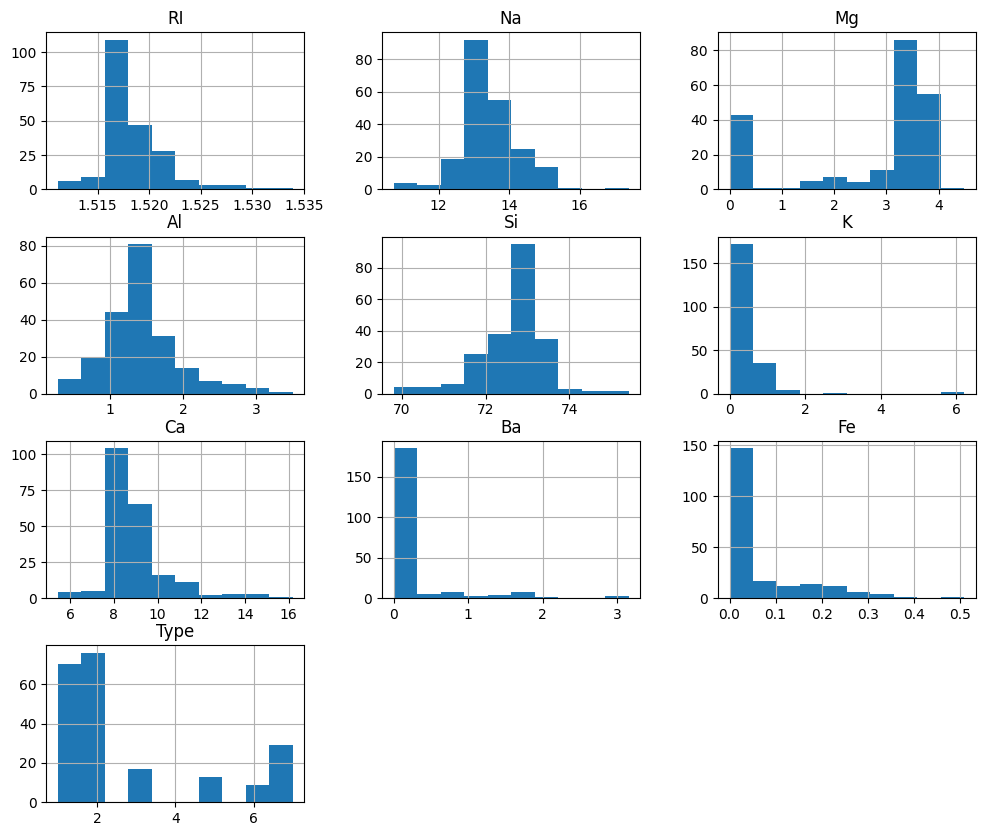

In [13]:
## histogram..
df.hist(figsize = (12, 10))
plt.show()

In [14]:
## From the histograms most features like RI , Na, Al, , Si and Ca appears to have a roughly normal or slight skewed distribution..
## However some features such as K, Ba and Fe are highly skewed with most of the values concentrated near zero and a few higher values..
## This confirms the presence of skewness and possible outliers in certain features.. 
## The target variable also shows an uneven distribution confirming class imbalance..

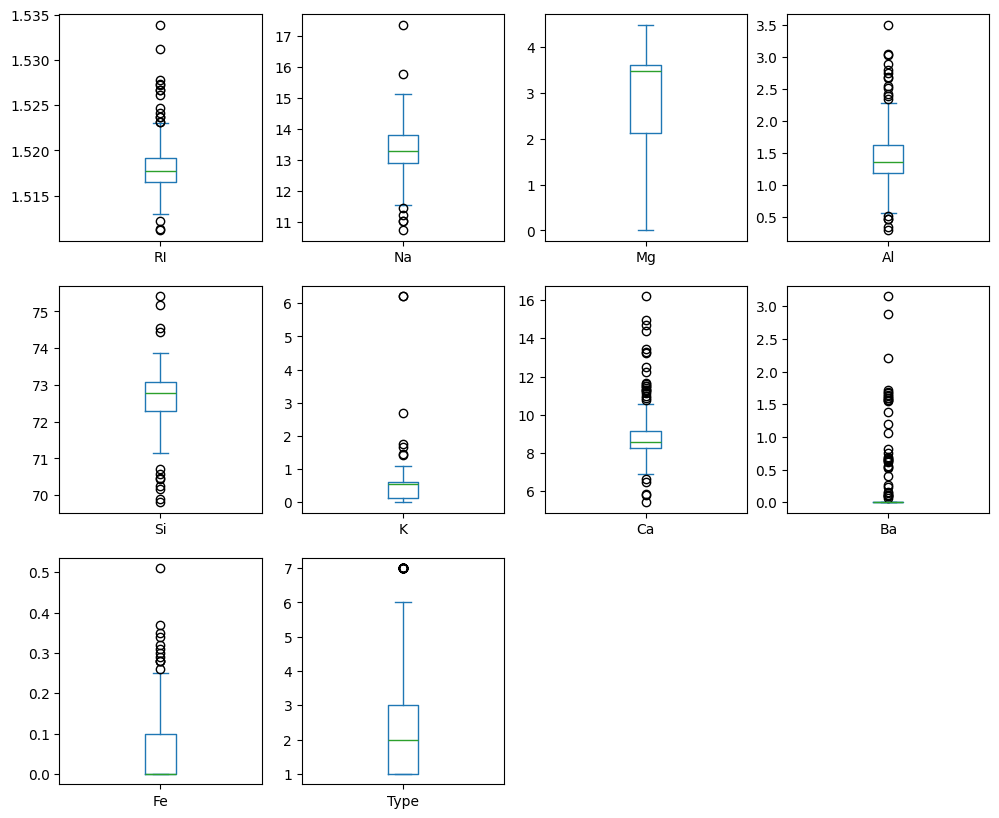

In [15]:
## Boxplot for outlier detection..
df.plot(kind = 'box', subplots = True, layout = (3,4), figsize = (12, 10))
plt.show()

## This is better way to plot boxplot because using subplots because we dont have to worry about the difference inscale between feature as each feature is having seperate boxplot..
## Hence we dont have to worry about feature with lower scale getting supperesed boxplot..

In [16]:
## Let calculate IQR and related statistic about outliers.. 
for i in df.columns:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    min_val = df[i].min()
    max_val = df[i].max()

    ## detect outliers..
    outliers = df[(df[i] < lower_bound) | (df[i] > upper_bound)][i]

    print(f"\nColumn: {i}")
    print(f"Q1 : {Q1}")
    print(f"Q3 : {Q3}")
    print(f"IQR : {IQR}")
    print(f"Lower Bound : {lower_bound}")
    print(f"Upper Bound : {upper_bound}")
    print(f"Minimum Value : {min_val}")
    print(f"Maximum Value : {max_val}")
    print(f"Potential Outiers : {len(outliers)}")
##    if len(outliers) > 0:
##        print("Potential Outliers:")
##        print(outliers.values)
    
##    plt.figure(figsize = (7, 2))
##    plt.boxplot(df[i].dropna(), vert = False)
##    plt.title(f"Boxplot of {i}")
##    plt.show()

    print("*"*100)


Column: RI
Q1 : 1.5165225
Q3 : 1.5191575
IQR : 0.002634999999999943
Lower Bound : 1.5125700000000002
Upper Bound : 1.52311
Minimum Value : 1.51115
Maximum Value : 1.53393
Potential Outiers : 17
****************************************************************************************************

Column: Na
Q1 : 12.9075
Q3 : 13.825
IQR : 0.9174999999999986
Lower Bound : 11.531250000000004
Upper Bound : 15.201249999999998
Minimum Value : 10.73
Maximum Value : 17.38
Potential Outiers : 7
****************************************************************************************************

Column: Mg
Q1 : 2.1149999999999998
Q3 : 3.6
IQR : 1.4850000000000003
Lower Bound : -0.11250000000000071
Upper Bound : 5.827500000000001
Minimum Value : 0.0
Maximum Value : 4.49
Potential Outiers : 0
****************************************************************************************************

Column: Al
Q1 : 1.19
Q3 : 1.63
IQR : 0.43999999999999995
Lower Bound : 0.53
Upper Bound : 2.29
Minimum Valu

In [17]:
## From the boxplots we can see that many features contain outliers.. 
## Columns like Ba, K, Fe, Ca and Al shows a large number of outliers specially Ba, which has extreme value spread far from the median..
## Some features like RI, Na and Si also have outliers but they seems to be comparitively fewer and less extreme..
## Overall the dataset clearly contains significant outliers particularly in Ba, K and Fe which also matches with what we saw in histograms (skewed distributions)..
## Anyway we need to keep this in mind that the dataset that we are using to small and random forest handle outliers better than other models so we won't we removing the outliers bluntly..

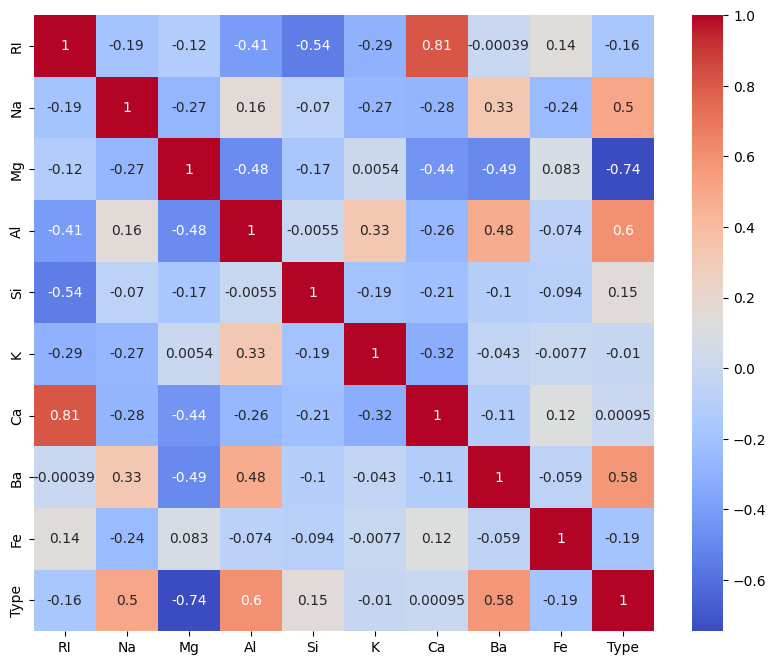

In [18]:
## Correlation heatmap..
import seaborn as sns

plt.figure(figsize = (10, 8))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.show()

In [19]:
## From the correlation heatmap we can see that some feature have strong relationships with each other.. 
## For example RI and Ca (0.81) show a strong positive correlation means when RI increases Ca also increases.. 
## Similarly Mg and Type (-0.74) show a strong negative correlation which means higher Mg values are associated with lower Type values..

## Also (Al and Type) (0.6) and (Ba and Type) (0.58) show moderate positive correlation which indicates they may be important features for predicting the target variable (Type)..
## Most other features show weak or very low correlation meaning they do not have a strong linear relationship with each other..

## Even if there is a correlation Random forest is not highly effected by multicollinearity so we usually dont drop features..

### 3: Data Preprocessing

In [20]:
## ● 1. Check for missing values in the dataset and decide on a strategy for handling them. Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.
## ● 2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.
## ● 3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. Handling the imbalance data.

In [21]:
## Missing values..
## I already checked it and found out that there were no missing values present in this dataset..
## Therefore no imputation or removal is required.. all data points are complete and can be directly used to build the model..

In [22]:
## Encoding..
## All the columns in the dataset are already in numerical from..
## Therefore no encoding technique has to be implemented or required..

In [23]:
## Feature scalling.. 
## Feature scaling is generally not required for random forest because it is a tree based model..
## It does not rely on distance based calculation so difference in feature scales do not affect the model performance..

In [24]:
## However since the assignment requires applying feature scaling so i will apply standardization to bring all features in same scale..
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X  = df.drop('Type', axis = 1) ## dropped the target variable
Y = df['Type']

X_scaled = scaler.fit_transform(X)

In [25]:
X_scaled

array([[ 0.87286765,  0.28495326,  1.25463857, ..., -0.14576634,
        -0.35287683, -0.5864509 ],
       [-0.24933347,  0.59181718,  0.63616803, ..., -0.79373376,
        -0.35287683, -0.5864509 ],
       [-0.72131806,  0.14993314,  0.60142249, ..., -0.82894938,
        -0.35287683, -0.5864509 ],
       ...,
       [ 0.75404635,  1.16872135, -1.86551055, ..., -0.36410319,
         2.95320036, -0.5864509 ],
       [-0.61239854,  1.19327046, -1.86551055, ..., -0.33593069,
         2.81208731, -0.5864509 ],
       [-0.41436305,  1.00915211, -1.86551055, ..., -0.23732695,
         3.01367739, -0.5864509 ]], shape=(214, 9))

In [26]:
## lets convert it to dataframe for better readability..
X_scaled = pd.DataFrame(X_scaled, columns = X.columns)
X_scaled.head(2)

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,0.872868,0.284953,1.254639,-0.692442,-1.127082,-0.671705,-0.145766,-0.352877,-0.586451
1,-0.249333,0.591817,0.636168,-0.170460,0.102319,-0.026213,-0.793734,-0.352877,-0.586451


In [27]:
## Standardization is successfully applied to the numerical features to bering them to a common scale with mean 0 and standard deviation 1..
## Although Random forest does not require scalling it was applied as per the assignment requirement.. 

In [28]:
## Handling imbalance.. 
## We already saw above that the target variable 'Type' is multiclass variable with 6 categories..
## Also the distribution of the class is uneven.. 
df['Type'].value_counts()

Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64

In [29]:
## There  are 2 major ways through which we can handle imbalance in this situation..
## First is by either combining the minority categories (7, 3, 5,6) together which will remove the imbalance and also reduce the total number of categories..
## Second is through 'class weights' method (higher importance given to mionority classes).. this helps model to learn from all classes and reduce bias toward majority ones..

## In our case its not ideal to use method first because dataset contains distinct classes representing different types of glass.. 
## Therefore combining minority classes will not be an appropriate idea as it would lead to loss of important information..

## Hence we will move ahead with second method 'class weights'

### 4: Random Forest Model Implementation

In [30]:
## ● 1. Divide the data into train and test split.
## ● 2. Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.
## ● 3. Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score

In [31]:
## Also, Although feature scaling was applied, the random forest model will be trained on the original dataset.. 
## Because tree based models are not affected by feature scalling..   

In [32]:
## Random forest model (with class weight)..
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [33]:
## We have already declared X and Y above.. 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

rf = RandomForestClassifier(class_weight = 'balanced', random_state = 42)
rf.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [34]:
## Evaluation.. 
## Using classification report we can get accuracy, precision, recall, and F1-score at once..
from sklearn.metrics import classification_report
Y_pred = rf.predict(X_test)

In [35]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           1       0.79      1.00      0.88        11
           2       0.85      0.79      0.81        14
           3       1.00      0.67      0.80         3
           5       1.00      0.50      0.67         4
           6       1.00      1.00      1.00         3
           7       0.89      1.00      0.94         8

    accuracy                           0.86        43
   macro avg       0.92      0.83      0.85        43
weighted avg       0.87      0.86      0.85        43



In [36]:
## The model accuracy is around 86% which can ve considered as a good output..
## If we look at individual classes some classes like 6 and 7 are predicted very well (almost perfect).. 
## This shows that model is learning even the minority classes properly which is a good sign..
## For class like 3 and 5 the recall is lower.. this means model is missing some actual casses of these classes.. 
## Overall the macro average and the weighted average  are good (0.85), this shows that model is performing balanced across different classes and not just focusing on majority classes..

## Using 'class weights' helped a lot, without it minority classes would have performed worse..

### 5: Bagging and Boosting Methods

In [37]:
## ● Apply the Bagging and Boosting methods and compare the results.

In [38]:
## Bagging = Bootstrap Aggregating..
## Here we train multiple models (base models) on different random samples of the data..each model sees slightly different data..
## Combine their prediction to get final output (Aggregating)..majority vote..
## Random forest = Bagging + base models are Decision trees + feature randomness.. 
## We already used random forest. now we will do basic bagging for comparison.. 

In [39]:
## Bagging classifier with Decision Tree
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [40]:
dt = DecisionTreeClassifier() ## Base model..

In [41]:
## Bagging model..
bag = BaggingClassifier(estimator = dt, n_estimators = 100, random_state = 42)

In [42]:
## Train 
bag.fit(X_train, Y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [43]:
## Predict
Y_pred_bag = bag.predict(X_test)

In [44]:
## Evaluation..
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           1       0.79      1.00      0.88        11
           2       0.85      0.79      0.81        14
           3       1.00      0.67      0.80         3
           5       1.00      0.50      0.67         4
           6       1.00      1.00      1.00         3
           7       0.89      1.00      0.94         8

    accuracy                           0.86        43
   macro avg       0.92      0.83      0.85        43
weighted avg       0.87      0.86      0.85        43



In [45]:
## Our bagging result = same as Random forest (0.86 accuracy)
## We go the exact same result for bagging as decision tree because both are ensemble method..
## Both use multiple decision trees..also data set is quite small..
## So there is not much os a difference in learing process of the models (base models).. 

In [46]:
## BOOSTING..
## Boosting = Model are trained one after another in a sequential form.. (Base models)..
## Here each new model focuses on mistake of previous model.. 
## In bagging base models were independent of each other and trained parallel but here base models depends on errors of previous base models..
## In boosting base models are same as bagging, Decision Tree.. only difference is that the base model that we use here decision stump.. because we want weak learner here..

## We will be using AdaBoost..
from sklearn.ensemble import AdaBoostClassifier

In [47]:
## Base model (weak learner)
dt_1 = DecisionTreeClassifier(max_depth = 2) ## here we took max depth = 1 because we want decision stump..

In [48]:
## Boosting model.. 
ada = AdaBoostClassifier(estimator = dt_1, n_estimators = 50, random_state = 42)

In [49]:
## Train
ada.fit(X_train, Y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=2)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [50]:
## Predict
Y_predict_ada = ada.predict(X_test)

In [51]:
## Evaluation 
print(classification_report(Y_test, Y_predict_ada))

              precision    recall  f1-score   support

           1       0.90      0.82      0.86        11
           2       0.80      0.86      0.83        14
           3       0.67      0.67      0.67         3
           5       0.67      0.50      0.57         4
           6       1.00      1.00      1.00         3
           7       0.89      1.00      0.94         8

    accuracy                           0.84        43
   macro avg       0.82      0.81      0.81        43
weighted avg       0.83      0.84      0.83        43



In [52]:
## The Boosting model (Adaboost) was applied to improve to improve the performance by focusing on the mistakes made by previous models..
## Initially whne the model was built using max_depth = 1, the accuracy acheived was very low (around 53%).. 
## This happened because base model tree were too weak..they probably failed to capture the complexity of patterns in data..
## Also because the dataset is multiclass dataset..
## Hence model failed to predict some paricular classes badly.. (precision for class 3 and 6 was 0.00)..

## So after increasing the max_depth = 2, the performance increased to around 84%.. 
## This shows that slightly stronger trees  were able to learn better patterns from the data.. 
## From this we can understand that boosting works well wil  weal learners but if base model are too simple tham model might underperform..
## So choosing right amount of complexity for base model is important for getting good results.. 

In [53]:
## Bagging vs Boosting result comparision.. 
## Bagging and random forest performed the best with an accuracy around 86%.. 
## Boosting gave an accuracy of 84% at max_depth = 2.. 
## Bagging and random forest worked better because they reduce variance and are more stable.. 
## Boosting on the other hand is sensitive to complexity of the base model and require proper tuning..

#### Additional Notes:

In [54]:
## ● 1. Explain Bagging and Boosting methods. How is it different from each other.
## ● 2. Explain how to handle imbalance in the data.

In [55]:
## Bagging vs Boosting..

## Bagging --> Bootstrap Aggregating..
## It is a technique where multiple base models are trained independently on different random samples of the data..
## Base models have low bias and high variance.. base models are trained parallel..  
## There predictions are combined using majority voting.. it helps reduce variance and improves model stability..

## Boosting is a technique where model are trained sequentially and each new model focuses on correcting the mistakes of the previous models..
## base model have typically high bioas and low variance (weak learner)
## It helps improving the accuracy by reducing the bias.. 

In [56]:
## Handelling imbalance data..
## Imbalance data occurs when some classes have significantly more samples than other..
## This can cause the model to become biased toward majority classes..

## To handle this we can use various techniques..
## 1) Class weight: Assing higher importance to minority classes..
## 2) Oversampling : Increase the samples of minority classes..
## 3) Undersampling : Reduce samples of majority classes.. 
## 4) SMOTE : Generates synthetic data for minority classes..

## In this particular assignment i used class weight which worked perfectly.. 